In [1]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='muted')

In [2]:
df = pd.read_csv(r"C:\Users\anike\OneDrive\Documents\Mysql Project\1 Nov Mysql Project E-commerce\ecommerce_sales_34500.csv")

In [3]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [4]:
# Data Clearing 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [5]:
df.shape

(34500, 17)

In [6]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [7]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [8]:
for col in df.columns:
    if col in ['category','payment_method','delivery_time_days','region','customer_gender']:
        print(df[col].unique())
        print("_________________________________________________________________________________________________________________________________")

['Home' 'Grocery' 'Electronics' 'Beauty' 'Fashion' 'Toys' 'Sports']
_________________________________________________________________________________________________________________________________
['Credit Card' 'UPI' 'COD' 'PayPal' 'Debit Card' 'Wallet']
_________________________________________________________________________________________________________________________________
[ 4  6  5  3  7  8  9 10 13 12]
_________________________________________________________________________________________________________________________________
['West' 'South' 'North' 'East' 'Central']
_________________________________________________________________________________________________________________________________
['Female' 'Male' 'Other']
_________________________________________________________________________________________________________________________________


In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  object        
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64   

In [11]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [12]:
df.returned.value_counts()

returned
No     32597
Yes     1903
Name: count, dtype: int64

In [13]:
df.duplicated().sum()

0

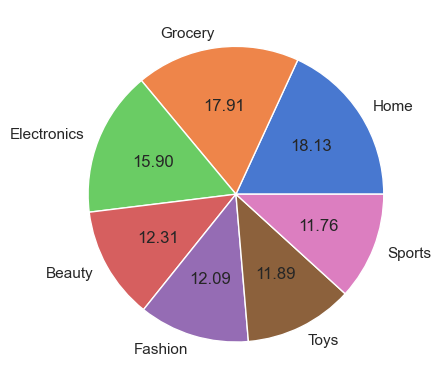

In [14]:
plt.pie(df['category'].value_counts(),labels = ['Home','Grocery','Electronics','Beauty','Fashion','Toys','Sports'],autopct = "%0.2f")
plt.show()

C:\Users\anike\AppData\Local\Temp\ipykernel_9668\437976016.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_gender', data=df, palette='pastel')


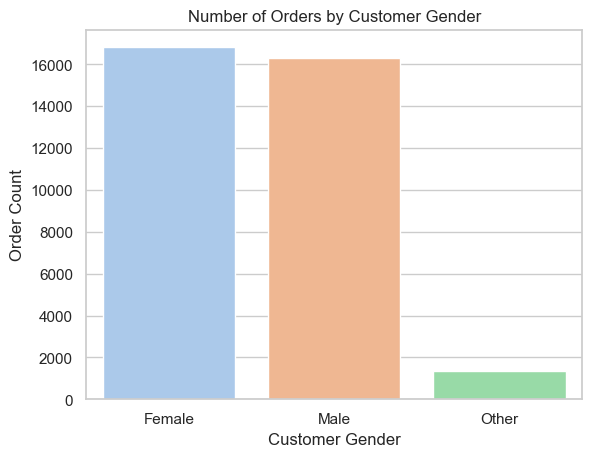

In [15]:
sns.countplot(x='customer_gender', data=df, palette='pastel')
plt.title('Number of Orders by Customer Gender')
plt.xlabel('Customer Gender')
plt.ylabel('Order Count')
plt.show()

In [16]:
df['returned'] = df['returned'].replace({'No':'0','Yes':'1'}).astype('int')

In [17]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,0,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,0,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,0,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,0,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,0,13.88,2.74,1.15,39,Male


In [18]:
df['returned'].value_counts()

returned
0    32597
1     1903
Name: count, dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  int32         
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64   

In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
price,34500.0,119.391632,1.01,16.69,45.66,130.95,2930.47,195.620477
discount,34500.0,0.049291,0.0,0.0,0.0,0.1,0.3,0.069894
quantity,34500.0,1.490725,1.0,1.0,1.0,2.0,5.0,0.93227
order_date,34500,2024-09-13 13:39:17.843478272,2023-09-12 00:00:00,2024-03-14 00:00:00,2024-09-16 00:00:00,2025-03-17 00:00:00,2025-09-11 00:00:00,NaN
delivery_time_days,34500.0,4.814203,3.0,4.0,5.0,6.0,13.0,1.242141
returned,34500.0,0.055159,0.0,0.0,0.0,0.0,1.0,0.228294
total_amount,34500.0,170.008494,0.82,19.71,56.82,168.53,12931.8,357.503014
shipping_cost,34500.0,6.15212,0.0,4.42,6.09,7.83,15.65,2.389539
profit_margin,34500.0,28.116505,-6.2,1.5,10.55,33.1325,1536.17,53.352947
customer_age,34500.0,43.474377,18.0,31.0,43.0,56.0,69.0,14.980682


In [21]:
# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['price', 'discount', 'quantity', 'delivery_time_days', 'returned',
       'total_amount', 'shipping_cost', 'profit_margin', 'customer_age'],
      dtype='object')

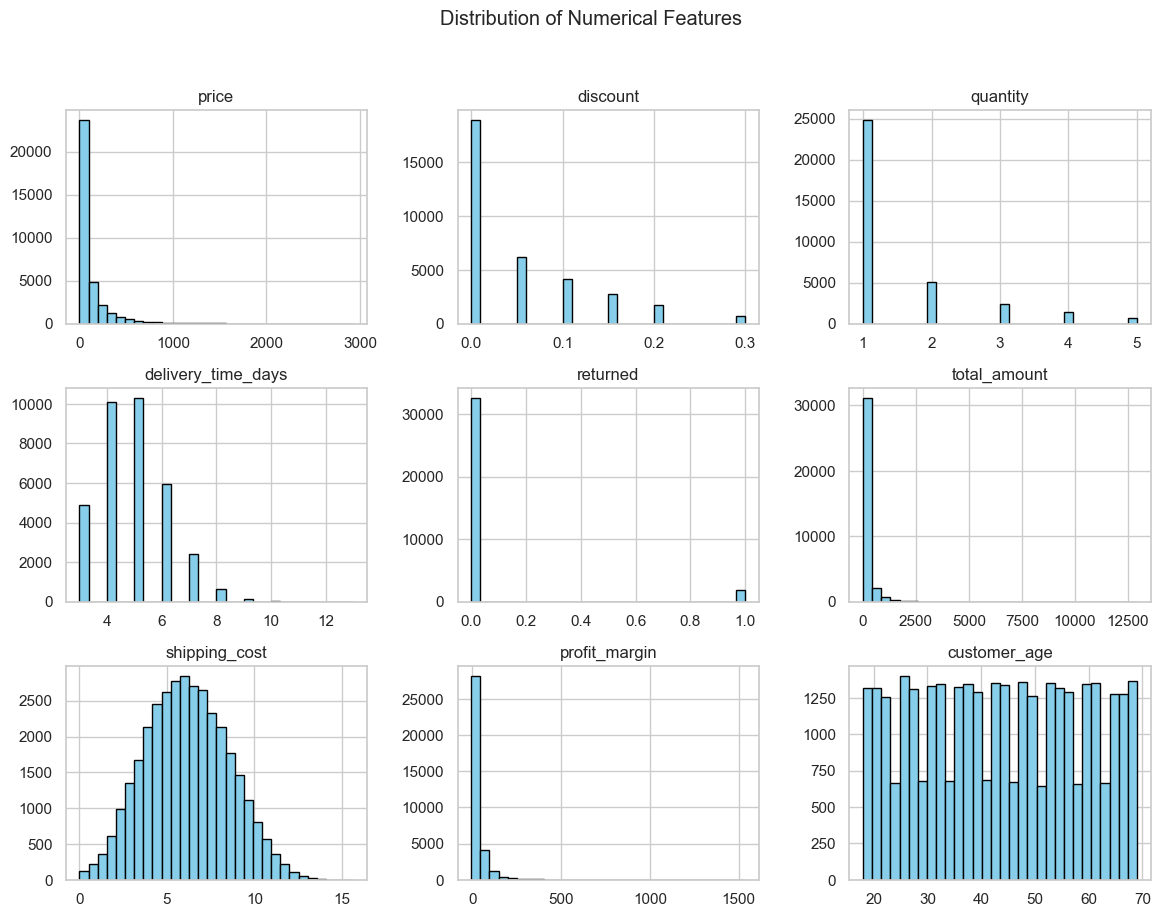

In [22]:
df[num_cols].hist(figsize=(14,10), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.show()

In [23]:
cat_cols = df.select_dtypes(exclude=np.number).columns
cat_cols

Index(['order_id', 'customer_id', 'product_id', 'category', 'payment_method',
       'order_date', 'region', 'customer_gender'],
      dtype='object')

C:\Users\anike\AppData\Local\Temp\ipykernel_9668\284766651.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_gender', y='total_amount', data=df, estimator=np.mean, palette='coolwarm')


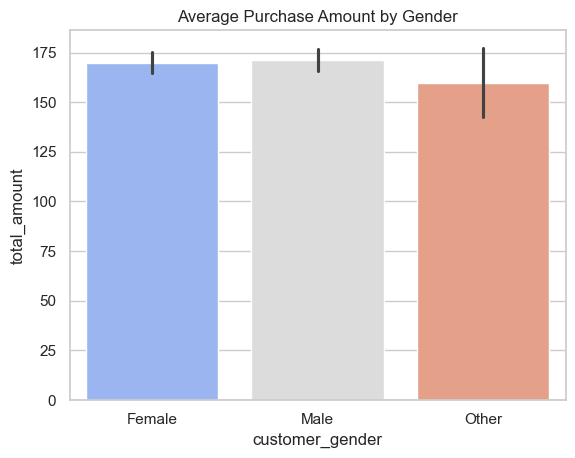

In [24]:
sns.barplot(x='customer_gender', y='total_amount', data=df, estimator=np.mean, palette='coolwarm')
plt.title('Average Purchase Amount by Gender')
plt.show()

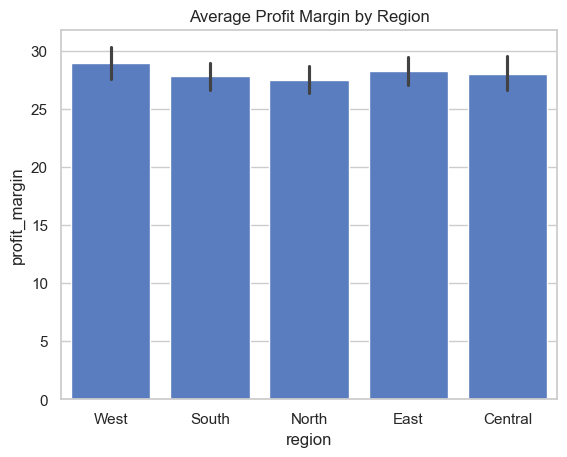

In [25]:
sns.barplot(x='region',y='profit_margin',data = df, estimator=np.mean)
plt.title('Average Profit Margin by Region')
plt.show()

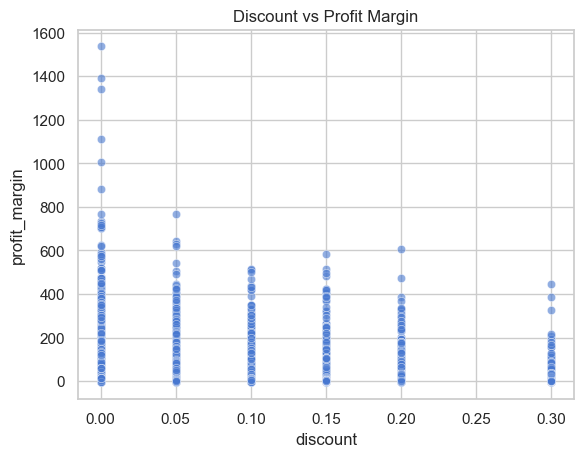

In [26]:
sns.scatterplot(x='discount', y='profit_margin', data=df, alpha=0.6)
plt.title('Discount vs Profit Margin')
plt.show()


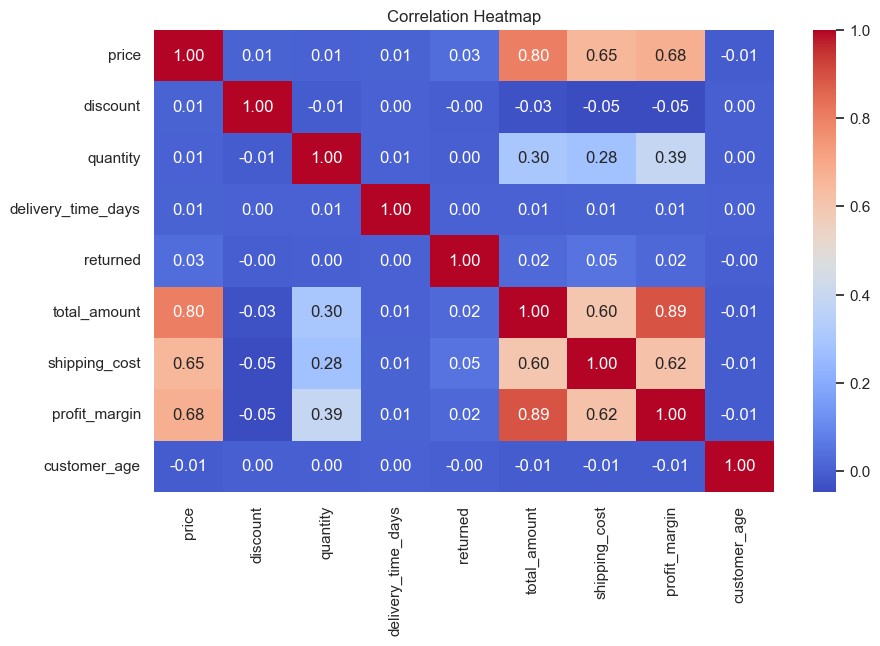

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


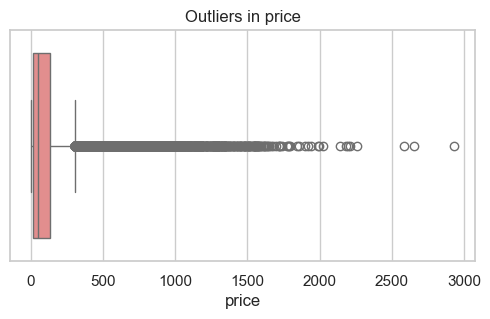

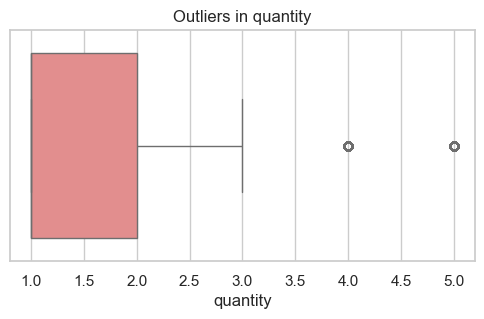

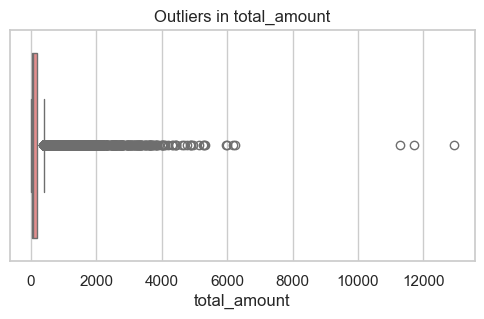

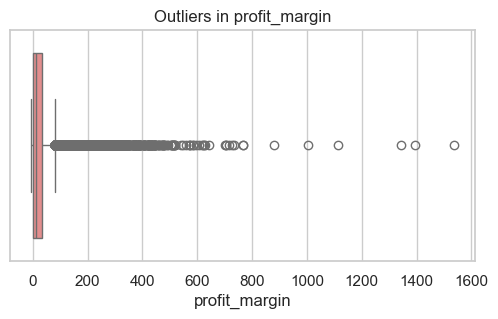

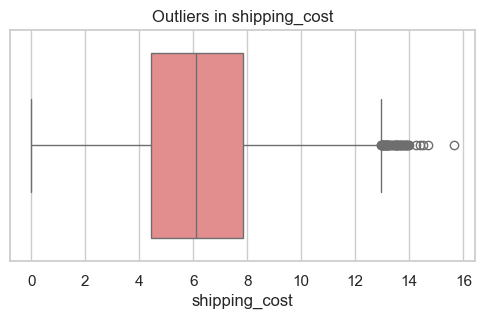

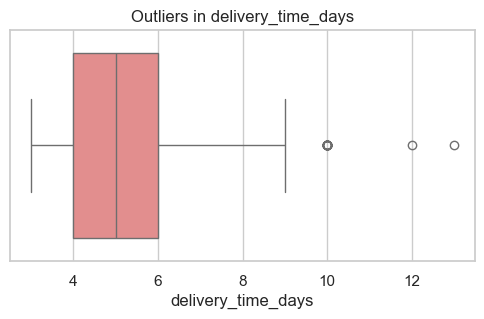

In [28]:
num_cols = ['price', 'quantity', 'total_amount', 'profit_margin', 'shipping_cost', 'delivery_time_days']
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Outliers in {col}')
    plt.show()


C:\Users\anike\AppData\Local\Temp\ipykernel_9668\127122169.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='returned', data=df, palette='pastel')


Text(0.5, 1.0, 'Return Distribution (1=Yes, 0=No)')

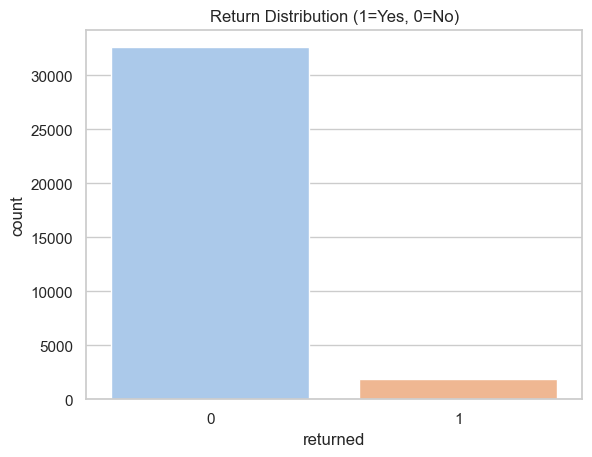

In [29]:
sns.countplot(x='returned', data=df, palette='pastel')
plt.title("Return Distribution (1=Yes, 0=No)")


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Home'),
  Text(1, 0, 'Grocery'),
  Text(2, 0, 'Electronics'),
  Text(3, 0, 'Beauty'),
  Text(4, 0, 'Fashion'),
  Text(5, 0, 'Toys'),
  Text(6, 0, 'Sports')])

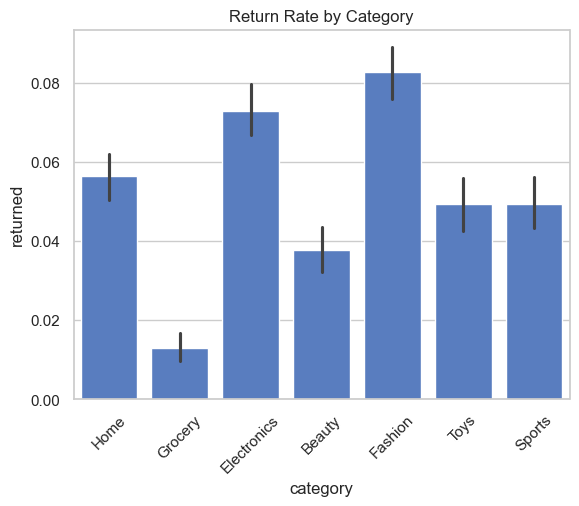

In [30]:
sns.barplot(x='category', y='returned', data=df, estimator=np.mean)
plt.title("Return Rate by Category")
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Discount vs Return Likelihood')

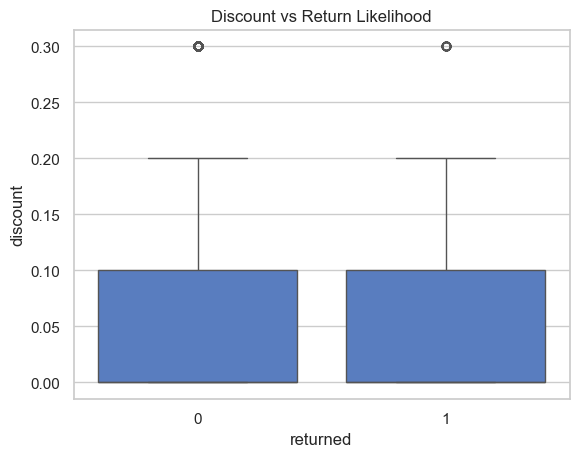

In [31]:
sns.boxplot(x='returned', y='discount', data=df)
plt.title("Discount vs Return Likelihood")


In [32]:
# Feature Engineering
df_encoded = pd.get_dummies(df, columns=['category', 'region', 'payment_method', 'customer_gender'], drop_first=True, dtype=int)


In [33]:
from imblearn.over_sampling import SMOTE

In [34]:
X = df_encoded.drop(['returned', 'order_id', 'order_date', 'customer_id', 'product_id'], axis=1)
y = df_encoded['returned']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [36]:
print("\nBefore SMOTE:")
print(y_train.value_counts(normalize=True))


Before SMOTE:
returned
0    0.94413
1    0.05587
Name: proportion, dtype: float64


In [37]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

C:\Users\anike\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\anike\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\anike\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anike\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\anike\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

In [38]:
print("\nAfter SMOTE:")
print(y_train_res.value_counts(normalize=True))


After SMOTE:
returned
0    0.5
1    0.5
Name: proportion, dtype: float64


In [39]:
model_lr = LogisticRegression(max_iter=500)
model_lr.fit(X_train_res, y_train_res)
y_pred_lr = model_lr.predict(X_test)

C:\Users\anike\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
print("\n🔹 Logistic Regression Results 🔹")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


🔹 Logistic Regression Results 🔹
Accuracy: 0.849

Confusion Matrix:
 [[5803  736]
 [ 304   57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.89      0.92      6539
           1       0.07      0.16      0.10       361

    accuracy                           0.85      6900
   macro avg       0.51      0.52      0.51      6900
weighted avg       0.90      0.85      0.87      6900



In [41]:
# Random Forest Classifier (Baseline)
# -------------------------------
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train_res, y_train_res)
y_pred_rf = model_rf.predict(X_test)

In [42]:
print("\n Random Forest Results ")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


 Random Forest Results 
Accuracy: 0.922

Confusion Matrix:
 [[6348  191]
 [ 350   11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      6539
           1       0.05      0.03      0.04       361

    accuracy                           0.92      6900
   macro avg       0.50      0.50      0.50      6900
weighted avg       0.90      0.92      0.91      6900



In [43]:
# ⚙️ PIPELINE MODEL (For Deployment)
cat_cols = ['category', 'region', 'payment_method', 'customer_gender']
num_cols = ['price', 'discount', 'quantity', 'delivery_time_days',
            'total_amount', 'profit_margin', 'shipping_cost', 'customer_age']

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [51]:
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced_subsample'
    ))
])

In [52]:
# Prepare data for pipeline
X_pipe = df[cat_cols + num_cols]
y_pipe = df['returned']

In [53]:
# Train-test split
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=42, stratify=y_pipe
)

In [54]:
# Train pipeline
from imblearn.pipeline import Pipeline 
pipeline_model.fit(X_train_pipe, y_train_pipe)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'region',
                                                   'payment_method',
                                                   'customer_gender']),
                                                 ('num', 'passthrough',
                                                  ['price', 'discount',
                                                   'quantity',
                                                   'delivery_time_days',
                                                   'total_amount',
                                                   'profit_margin',
                                                   'shipping_cost',
                                                   'customer_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=200, random_state=42))])

In [55]:
# Evaluate
y_pred_pipe = pipeline_model.predict(X_test_pipe)
print("\n🚀 PIPELINE MODEL RESULTS 🚀")
print("Accuracy:", round(accuracy_score(y_test_pipe, y_pred_pipe), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_pipe, y_pred_pipe))
print("\nClassification Report:\n", classification_report(y_test_pipe, y_pred_pipe))



🚀 PIPELINE MODEL RESULTS 🚀
Accuracy: 0.944

Confusion Matrix:
 [[6515    4]
 [ 381    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      6519
           1       0.00      0.00      0.00       381

    accuracy                           0.94      6900
   macro avg       0.47      0.50      0.49      6900
weighted avg       0.89      0.94      0.92      6900



Text(0.5, 1.0, 'Confusion Matrix')

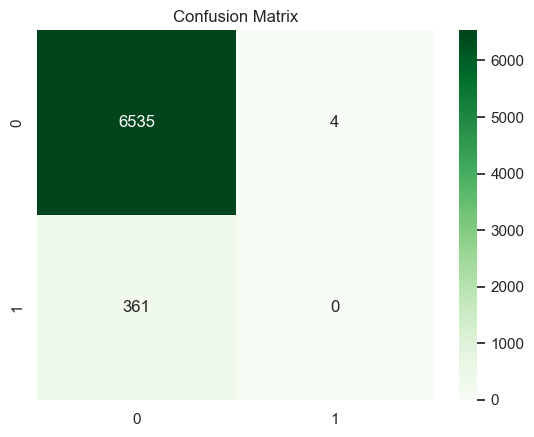

In [56]:
sns.heatmap(confusion_matrix(y_test, y_pred_pipe), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')


In [57]:
# ✅ Save full pipeline model
joblib.dump(pipeline_model, 'return_predictor_2.pkl')
print("\n✅ Pipeline model saved as return_predictor.pkl")


✅ Pipeline model saved as return_predictor.pkl
